In [1]:
#import packages
import numpy as np
from scipy.optimize import minimize
import weighted_maxcut_qaoa as qaoa #this is a .py file with my qaoa code
from qiskit.visualization import plot_histogram
import networkx as nx
from time import time
from matplotlib import pyplot as plt
plt.style.use('seaborn')

# Weighted Max-Cut

#### Application: Clustering within Autonomous Sensor Data

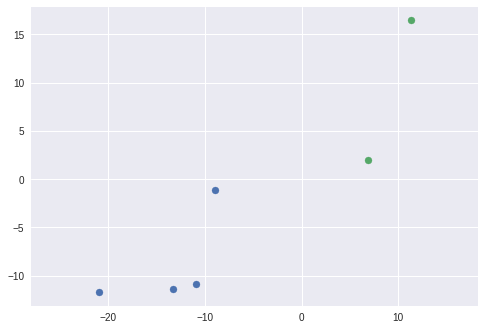

In [2]:
# set up two random distributions with n_points total points and plot
n1 = 4
n2 = 2
n_points = n1 + n2
set1  = np.random.normal(-10, 5, (2, n1))
set2 = np.random.normal(10, 5, (2, n2))
plt.scatter(set1[0, :], set1[1, :])
plt.scatter(set2[0, :], set2[1, :])
plt.axis('equal')
plt.show()     

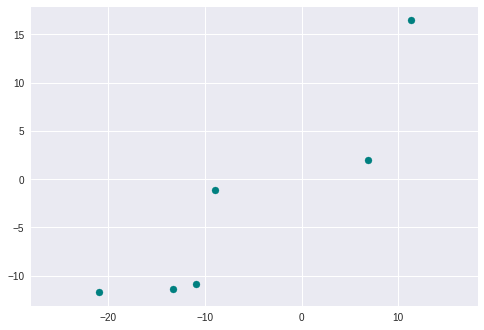

In [3]:
# create a dictionary mapping points to nodes
combined_set = np.hstack((set1, set2))
ind = np.arange(n_points)
np.random.shuffle(ind)
combined_set = combined_set[:, ind]
nodes_points = dict()
counter = 0
for column in range(combined_set.shape[1]):
    nodes_points[counter] = combined_set[:, column]
    counter += 1
nodes = nodes_points.keys()
plt.scatter(combined_set[0, :], combined_set[1, :], color='teal')
plt.axis('equal')
plt.show()

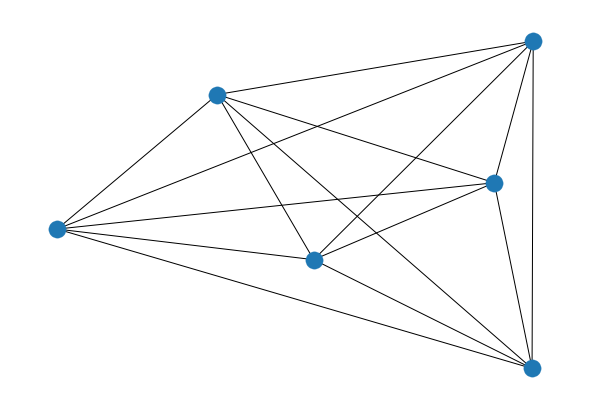

In [4]:
# now set up edges with weights corresponding to distances between nodes/points
G = nx.Graph()
for node1 in nodes:
    point1 = nodes_points[node1]
    for node2 in nodes:
        if node2 == node1:
            continue
        point2 = nodes_points[node2]
        weight = np.linalg.norm(point1 - point2)
        G.add_edge(node1, node2, weight=weight)

# draw the graph (note that weight is not reflected here as of now, gets messy)
nx.draw(G)

In [5]:
# get the expectation function from qaoa.py
start = time()
n_layers = 32 #number of layers (scale it up linearly with n_points)
shots = 512
expectation = qaoa.get_expectation(G, n_layers, shots)

# minimize the expectation by running the circuit
initial_params = .01*np.random.uniform(-1, 1, 2*n_layers)
sol = minimize(expectation, initial_params, method='COBYLA')
counts = expectation(sol.x, return_counts=True)[1]
print(sol)

# get the optimal bitstring we found and print it, along with other stats
true1 = ['0' for x in range(n1)]
true2 = ['1' for x in range(n2)]
true_bitstring = ''.join(np.concatenate((true1, true2))[ind])
found_bitstring = list(counts.keys())[np.argmax(list(counts.values()))]
print('\nTrue Optimal Bitstring: ' + true_bitstring)
print('Found Bitstring: ' + found_bitstring)
print('Runtime: ' + str(round(time() - start, 2)) + ' seconds')

     fun: -184.79205927233102
   maxcv: 0.0
 message: 'Optimization terminated successfully.'
    nfev: 507
  status: 1
 success: True
       x: array([ 1.24602048e+00,  7.74603503e-03,  1.00417355e-02, -3.82227906e-02,
        1.80762235e-02,  8.23248693e-03,  5.51703872e-03,  1.59995486e-02,
        1.57130743e-02,  1.11809149e-02,  1.51871575e-01,  6.92799297e-03,
       -1.79323348e-01,  1.79171083e-02,  7.31277340e-03, -9.97662939e-02,
        4.81675088e-02,  2.20849756e-02,  1.98123499e-02,  2.51666236e-02,
        2.99338610e-02,  2.34593967e-02,  1.95756722e-02,  8.17679661e-03,
        2.35107668e-02,  3.80678438e-03,  2.41674321e-02,  1.71885818e-02,
       -1.14918445e-03,  9.72491811e-03,  2.16714035e-02,  8.89990022e-03,
        1.29324322e-02,  1.02120395e+00,  6.64275290e-04, -3.99003333e-03,
       -5.30980971e-03,  1.12312177e-02,  1.85056072e-03,  1.15106236e-02,
       -4.64508375e-03,  1.01553718e-02, -5.54616260e-03,  2.00263392e-01,
       -1.59626766e-01,  6.190

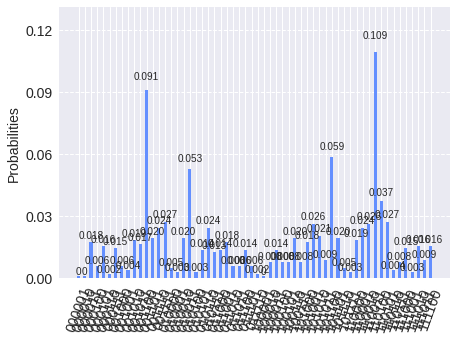

In [6]:
# plot a histogram of the bitstring counts using our optimized parameters
plot_histogram(counts)
# np.sum(list(counts.values()))

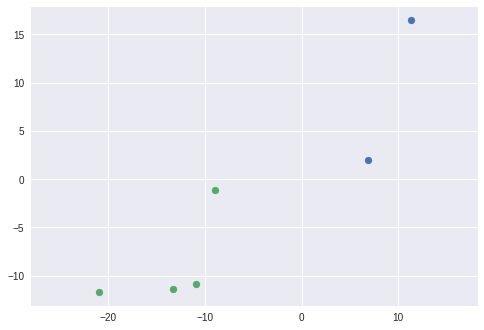

In [7]:
# convert the result back to points separated by the cut we found above
cluster0, cluster1 = [], []
counter = 0
for char in found_bitstring:
    if int(char) == 0:
        cluster0.append(nodes_points[counter])
    else:
        cluster1.append(nodes_points[counter])
    counter += 1

# plot our points/clusters
cluster0 = np.vstack((cluster0)).T
plt.scatter(cluster0[0, :], cluster0[1, :])
cluster1 = np.vstack((cluster1)).T
plt.scatter(cluster1[0, :], cluster1[1, :])
plt.axis('equal')
plt.show()

In [8]:
qaoa.maxcut_obj(true_bitstring, G), qaoa.maxcut_obj(found_bitstring, G), true_bitstring, found_bitstring

(-235.5307072342827, -235.5307072342827, '001100', '110011')